# ClinicalBERT Medical Document Classifier Fine-Tuning
This notebook fine-tunes a production-quality medical document classifier using `Bio_ClinicalBERT`.

### Pipeline & Strategy:
1. **Model**: Emily Alsentzer's `Bio_ClinicalBERT` (from Hugging Face).
2. **Dataset**: 256 reports from `outputs/ocr_dataset.csv` with 7 target report classes.
3. **CPU-Optimized Training Strategy**:
   - Embeddings and early transformer layers (layers 0-9) are **frozen**.
   - The final transformer layers (layers 10-11) and the classification head are **fine-tuned**.
   - This drastically cuts down CPU training times while retaining high quality.
4. **Early Stopping & Checkpoint Saving**: Monitors validation loss, saving the best model and stopping early to prevent overfitting.
5. **Evaluation**: Outputs F1-Score, Classification Report, and Confusion Matrix.


In [1]:
import os
import sys
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Ensure UTF-8 output formatting for Windows console/notebook
import io
sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8') if hasattr(sys.stdout, 'buffer') else sys.stdout
sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8') if hasattr(sys.stderr, 'buffer') else sys.stderr

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch Version: 2.12.0+cpu
CUDA Available: False
Using device: cpu


## Load Data & Encode Labels
We load the extracted OCR text dataset and apply `LabelEncoder` for the 7 medical report classes.


In [2]:
# Setup paths
DATA_PATH = "../outputs/ocr_dataset.csv"
MODEL_SAVE_DIR = "../models/clinicalbert_classifier"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Load CSV
df = pd.read_csv(DATA_PATH)
df['text'] = df['text'].fillna("")
df['label'] = df['label'].str.lower().str.strip()

print(f"Loaded dataset: {df.shape[0]} records")
print("\nLabel distribution:")
print(df['label'].value_counts())

# Encode labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Save Label Encoder
label_encoder_path = os.path.join(MODEL_SAVE_DIR, "label_encoder.pkl")
with open(label_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"\nLabel Encoder saved to: {label_encoder_path}")
print("Classes mapped:", list(label_encoder.classes_))


Loaded dataset: 256 records

Label distribution:
label
cbc                     62
haematology             48
lft                     40
kidney_function_test    31
urine                   29
microbiology            27
crp                     19
Name: count, dtype: int64

Label Encoder saved to: ../models/clinicalbert_classifier\label_encoder.pkl
Classes mapped: ['cbc', 'crp', 'haematology', 'kidney_function_test', 'lft', 'microbiology', 'urine']


## Stratified Train-Test Split
We split the dataset into 80% training and 20% validation, stratified by labels to keep classes balanced.


In [3]:
# Stratified split
train_df, val_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['label_encoded']
)

print(f"Training set: {train_df.shape[0]} records")
print(f"Validation set: {val_df.shape[0]} records")


Training set: 204 records
Validation set: 52 records


## PyTorch Dataset & DataLoader
Define our custom `MedicalReportDataset` that handles Hugging Face tokenization (Bio_ClinicalBERT) with padding and truncation.


In [4]:
class MedicalReportDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize Tokenizer
print("Loading Bio_ClinicalBERT Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"Tokenizer saved to: {MODEL_SAVE_DIR}")

# Create Datasets
train_dataset = MedicalReportDataset(
    texts=train_df['text'].values,
    labels=train_df['label_encoded'].values,
    tokenizer=tokenizer
)

val_dataset = MedicalReportDataset(
    texts=val_df['text'].values,
    labels=val_df['label_encoded'].values,
    tokenizer=tokenizer
)

# DataLoaders (using batch size = 8 for fast CPU execution)
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

print(f"DataLoaders created. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Loading Bio_ClinicalBERT Tokenizer...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

C:\Users\Vivek\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Vivek\.cache\huggingface\hub\models--emilyalsentzer--Bio_ClinicalBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Tokenizer saved to: ../models/clinicalbert_classifier
DataLoaders created. Train batches: 26 | Val batches: 7


## Model Initialization & Layer Freezing Strategy
To optimize training speed on CPU, we freeze the word embeddings and the first 10 transformer encoder layers (layers 0 to 9) of Bio_ClinicalBERT, fine-tuning only the final 2 transformer layers (10 and 11) and the classification head.


In [5]:
print("Loading Bio_ClinicalBERT Model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "emilyalsentzer/Bio_ClinicalBERT", 
    num_labels=7
)

# Layer Freezing Strategy:
# 1. Freeze embeddings
for param in model.bert.embeddings.parameters():
    param.requires_grad = False

# 2. Freeze layers 0 to 9
for layer in model.bert.encoder.layer[:10]:
    for param in layer.parameters():
        param.requires_grad = False

# Count trainable vs frozen parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\nModel Parameter Summary:")
print(f"  - Total parameters: {total_params:,}")
print(f"  - Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.2f}%)")
print(f"  - Frozen parameters: {frozen_params:,} ({frozen_params/total_params*100:.2f}%)")

model = model.to(device)


Loading Bio_ClinicalBERT Model...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec


Model Parameter Summary:
  - Total parameters: 108,315,655
  - Trainable parameters: 14,771,719 (13.64%)
  - Frozen parameters: 93,543,936 (86.36%)


## Training & Validation Loop with Early Stopping
We set up cross-entropy loss, AdamW optimizer, model checkpointing, and early stopping (patience = 3 epochs).


In [6]:
# Training Config
EPOCHS = 6
learning_rate = 2e-5
optimizer = AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Early stopping & Checkpointing config
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
val_losses = []

print("Starting training loop...")
for epoch in range(1, EPOCHS + 1):
    epoch_start_time = time.time()
    
    # --- Train loop ---
    model.train()
    total_train_loss = 0
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation loop ---
    model.eval()
    total_val_loss = 0
    val_preds = []
    val_labels = []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()
            
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            
            val_preds.extend(preds)
            val_labels.extend(labels.cpu().numpy())
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Compute accuracy for progress print
    val_acc = accuracy_score(val_labels, val_preds)
    epoch_time = time.time() - epoch_start_time
    
    print(f"Epoch {epoch} complete | Time: {epoch_time:.1f}s")
    print(f"  - Train Loss: {avg_train_loss:.4f}")
    print(f"  - Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # --- Checkpoint & Early Stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        
        # Save best model checkpoint
        model.save_pretrained(MODEL_SAVE_DIR)
        print(f"  => Saved new best model checkpoint to: {MODEL_SAVE_DIR}")
    else:
        epochs_no_improve += 1
        print(f"  => Val loss did not improve. (Patience remaining: {patience - epochs_no_improve})")
        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered. Training stopped.")
            break


Starting training loop...


Epoch 1/6 [Train]:   0%|          | 0/26 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Epoch 1/6 [Train]:   4%|▍         | 1/26 [00:07<03:19,  7.98s/it]

Epoch 1/6 [Train]:   8%|▊         | 2/26 [00:16<03:21,  8.41s/it]

...

Epoch 6/6 [Val]: 100%|██████████| 7/7 [00:27<00:00,  3.59s/it]

Epoch 6/6 [Val]: 100%|██████████| 7/7 [00:27<00:00,  3.98s/it]

Epoch 6 complete | Time: 264.6s
  - Train Loss: 1.5115
  - Val Loss: 1.5821 | Val Acc: 0.3654


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  => Saved new best model checkpoint to: ../models/clinicalbert_classifier


## Model Performance Evaluation
We load the best saved model checkpoint and run a full evaluation on the validation set, reporting Accuracy, Precision, Recall, F1-Score, Classification Report, and plotting the Confusion Matrix.


Loading best model checkpoint for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

C:\Users\Vivek\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Vivek\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Vivek\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Vivek\anaconda3\Lib

================ EVALUATION METRICS ================
Accuracy:  0.3654
Precision: 0.2995
Recall:    0.3654
F1 Score:  0.3196

Classification Report:
                      precision    recall  f1-score   support

                 cbc       0.53      0.77      0.62        13
                 crp       0.00      0.00      0.00         4
         haematology       0.10      0.20      0.13        10
kidney_function_test       0.00      0.00      0.00         6
                 lft       0.56      0.62      0.59         8
        microbiology       0.67      0.40      0.50         5
               urine       0.00      0.00      0.00         6

            accuracy                           0.37        52
           macro avg       0.26      0.28      0.26        52
        weighted avg       0.30      0.37      0.32        52



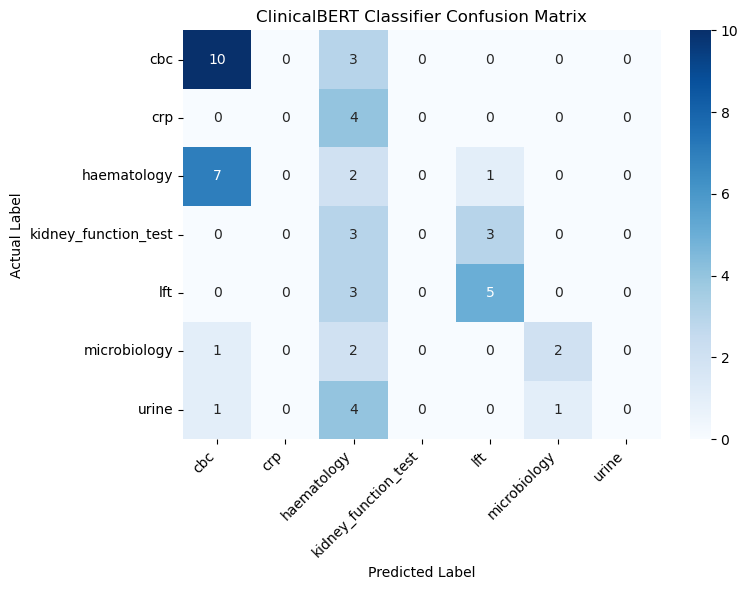

In [7]:
# Load the best saved checkpoint
print("Loading best model checkpoint for evaluation...")
best_model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
best_model = best_model.to(device)
best_model.eval()

# Run validation inference
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = best_model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# Compute Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

print("================ EVALUATION METRICS ================")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("====================================================\n")

# Print Classification Report
class_names = list(label_encoder.classes_)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Generate Confusion Matrix Plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('ClinicalBERT Classifier Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Real-time Prediction Pipeline Check
Let's define a prediction function that accepts raw text, preprocesses it, tokenizes it, and returns the predicted label along with the confidence score.


In [8]:
def predict_report_type(text, model, tokenizer, label_encoder):
    """
    Performs inference on raw text using our fine-tuned ClinicalBERT model.
    """
    model.eval()
    
    # Tokenize input
    inputs = tokenizer(
        text,
        add_special_tokens=True,
        max_length=512,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1).flatten()
        
        # Get max score
        pred_idx = torch.argmax(probabilities).item()
        confidence = probabilities[pred_idx].item()
        
    prediction = label_encoder.inverse_transform([pred_idx])[0]
    
    return {
        "prediction": prediction,
        "confidence": round(confidence, 4)
    }

# Quick test case
sample_input = "Haemoglobin WBC RBC Platelet Count"
result = predict_report_type(sample_input, best_model, tokenizer, label_encoder)
print("Example Input:", sample_input)
print("Prediction Output:", result)


Example Input: Haemoglobin WBC RBC Platelet Count
Prediction Output: {'prediction': 'kidney_function_test', 'confidence': 0.2415}
